# Do SAE features add information beyond surprisal?

Read **SAE gain (pp)** first, then its interval and the paired **SAE minus dense** contrast. Both hook and regularization strength are chosen using training stories only. These exploratory aggregate-RT results do not establish feature meaning or human mechanisms.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.report_bundle import read_summary, verify_bundle
from src.utils import focus_table, display_details
REPORTS = Path(os.environ.get("SAERT_REPORTS_DIR", ROOT/"reports"))
verify_bundle(REPORTS)
def load(section, name): return read_summary(section, name, REPORTS)
def figure(section, name): display(Image(filename=str(REPORTS/section/(name+".png"))))


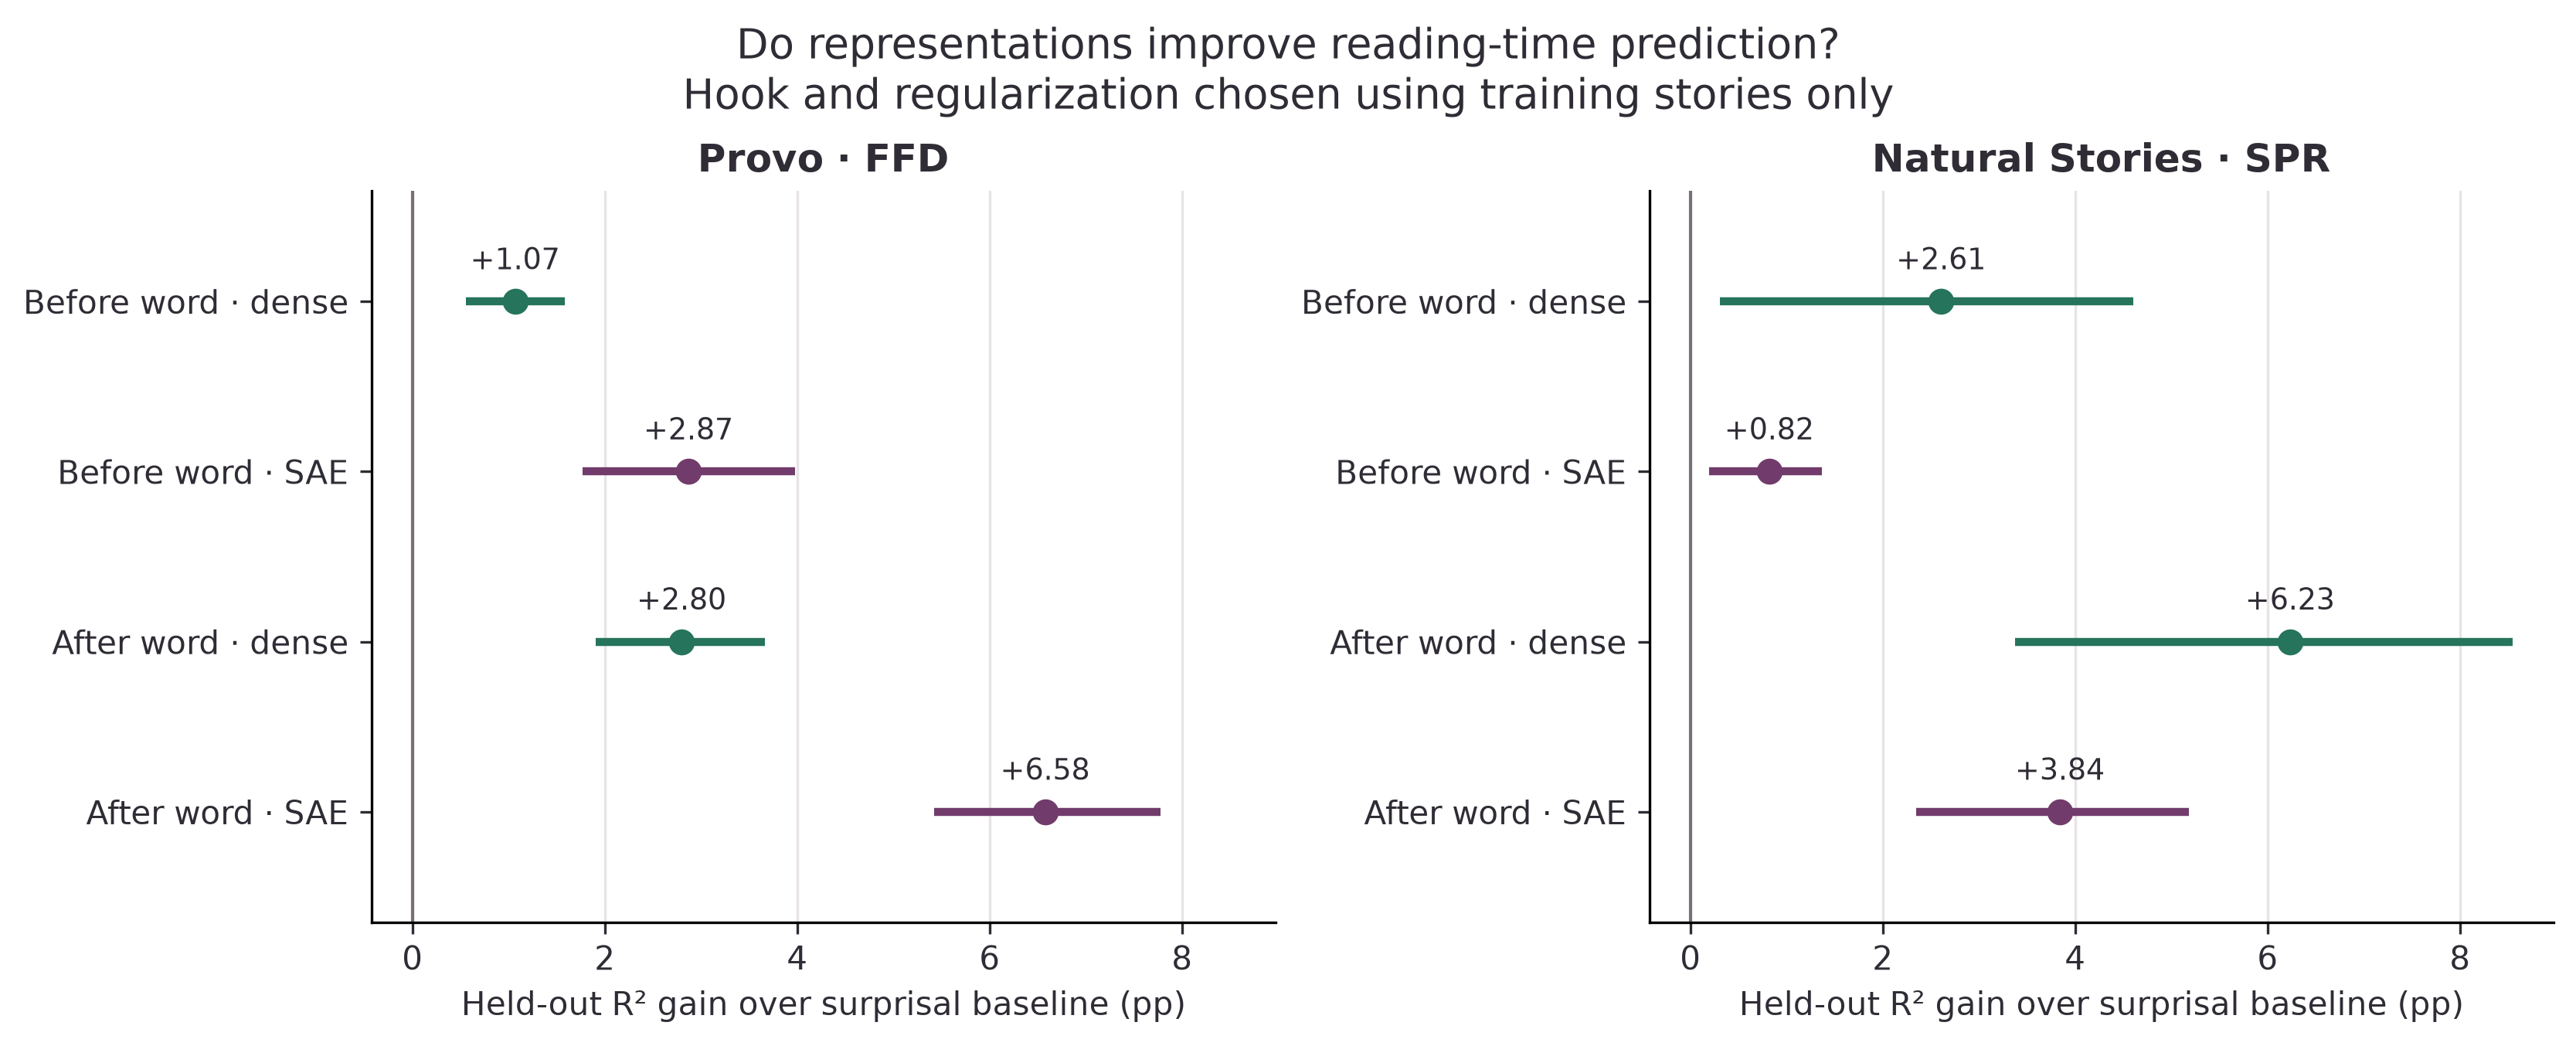

In [2]:
figure("sae_prediction","heldout_representation_gain")

In [3]:
primary = load("sae_prediction","primary_results")
display(focus_table(primary[["Corpus","State","SAE gain (pp)","SAE 95% interval","Texts improved"]],
 important=["SAE gain (pp)"],signed_columns=["SAE gain (pp)"],formats={"SAE gain (pp)":"{:+.2f}"}))
display(focus_table(primary[["Corpus","State","SAE minus dense (pp)","Difference 95% interval"]],
 important=["SAE minus dense (pp)"],signed_columns=["SAE minus dense (pp)"],formats={"SAE minus dense (pp)":"{:+.2f}"}))

Corpus,State,SAE gain (pp),SAE 95% interval,Texts improved
Provo · FFD,Before word,+2.87,"[+1.77, +3.98]",43/55
Provo · FFD,After word,+6.58,"[+5.42, +7.78]",50/55
Natural Stories · SPR,Before word,+0.82,"[+0.19, +1.37]",7/10
Natural Stories · SPR,After word,+3.84,"[+2.35, +5.18]",10/10


Corpus,State,SAE minus dense (pp),Difference 95% interval
Provo · FFD,Before word,+1.80,"[+0.67, +2.88]"
Provo · FFD,After word,+3.78,"[+2.73, +4.88]"
Natural Stories · SPR,Before word,-1.79,"[-3.49, +0.25]"
Natural Stories · SPR,After word,-2.39,"[-4.02, -0.45]"


After-word states observe the target word. Confidence intervals condition on fixed predictions and exclude participant/refitting uncertainty. Dense and SAE representations differ in width and nonlinearity.

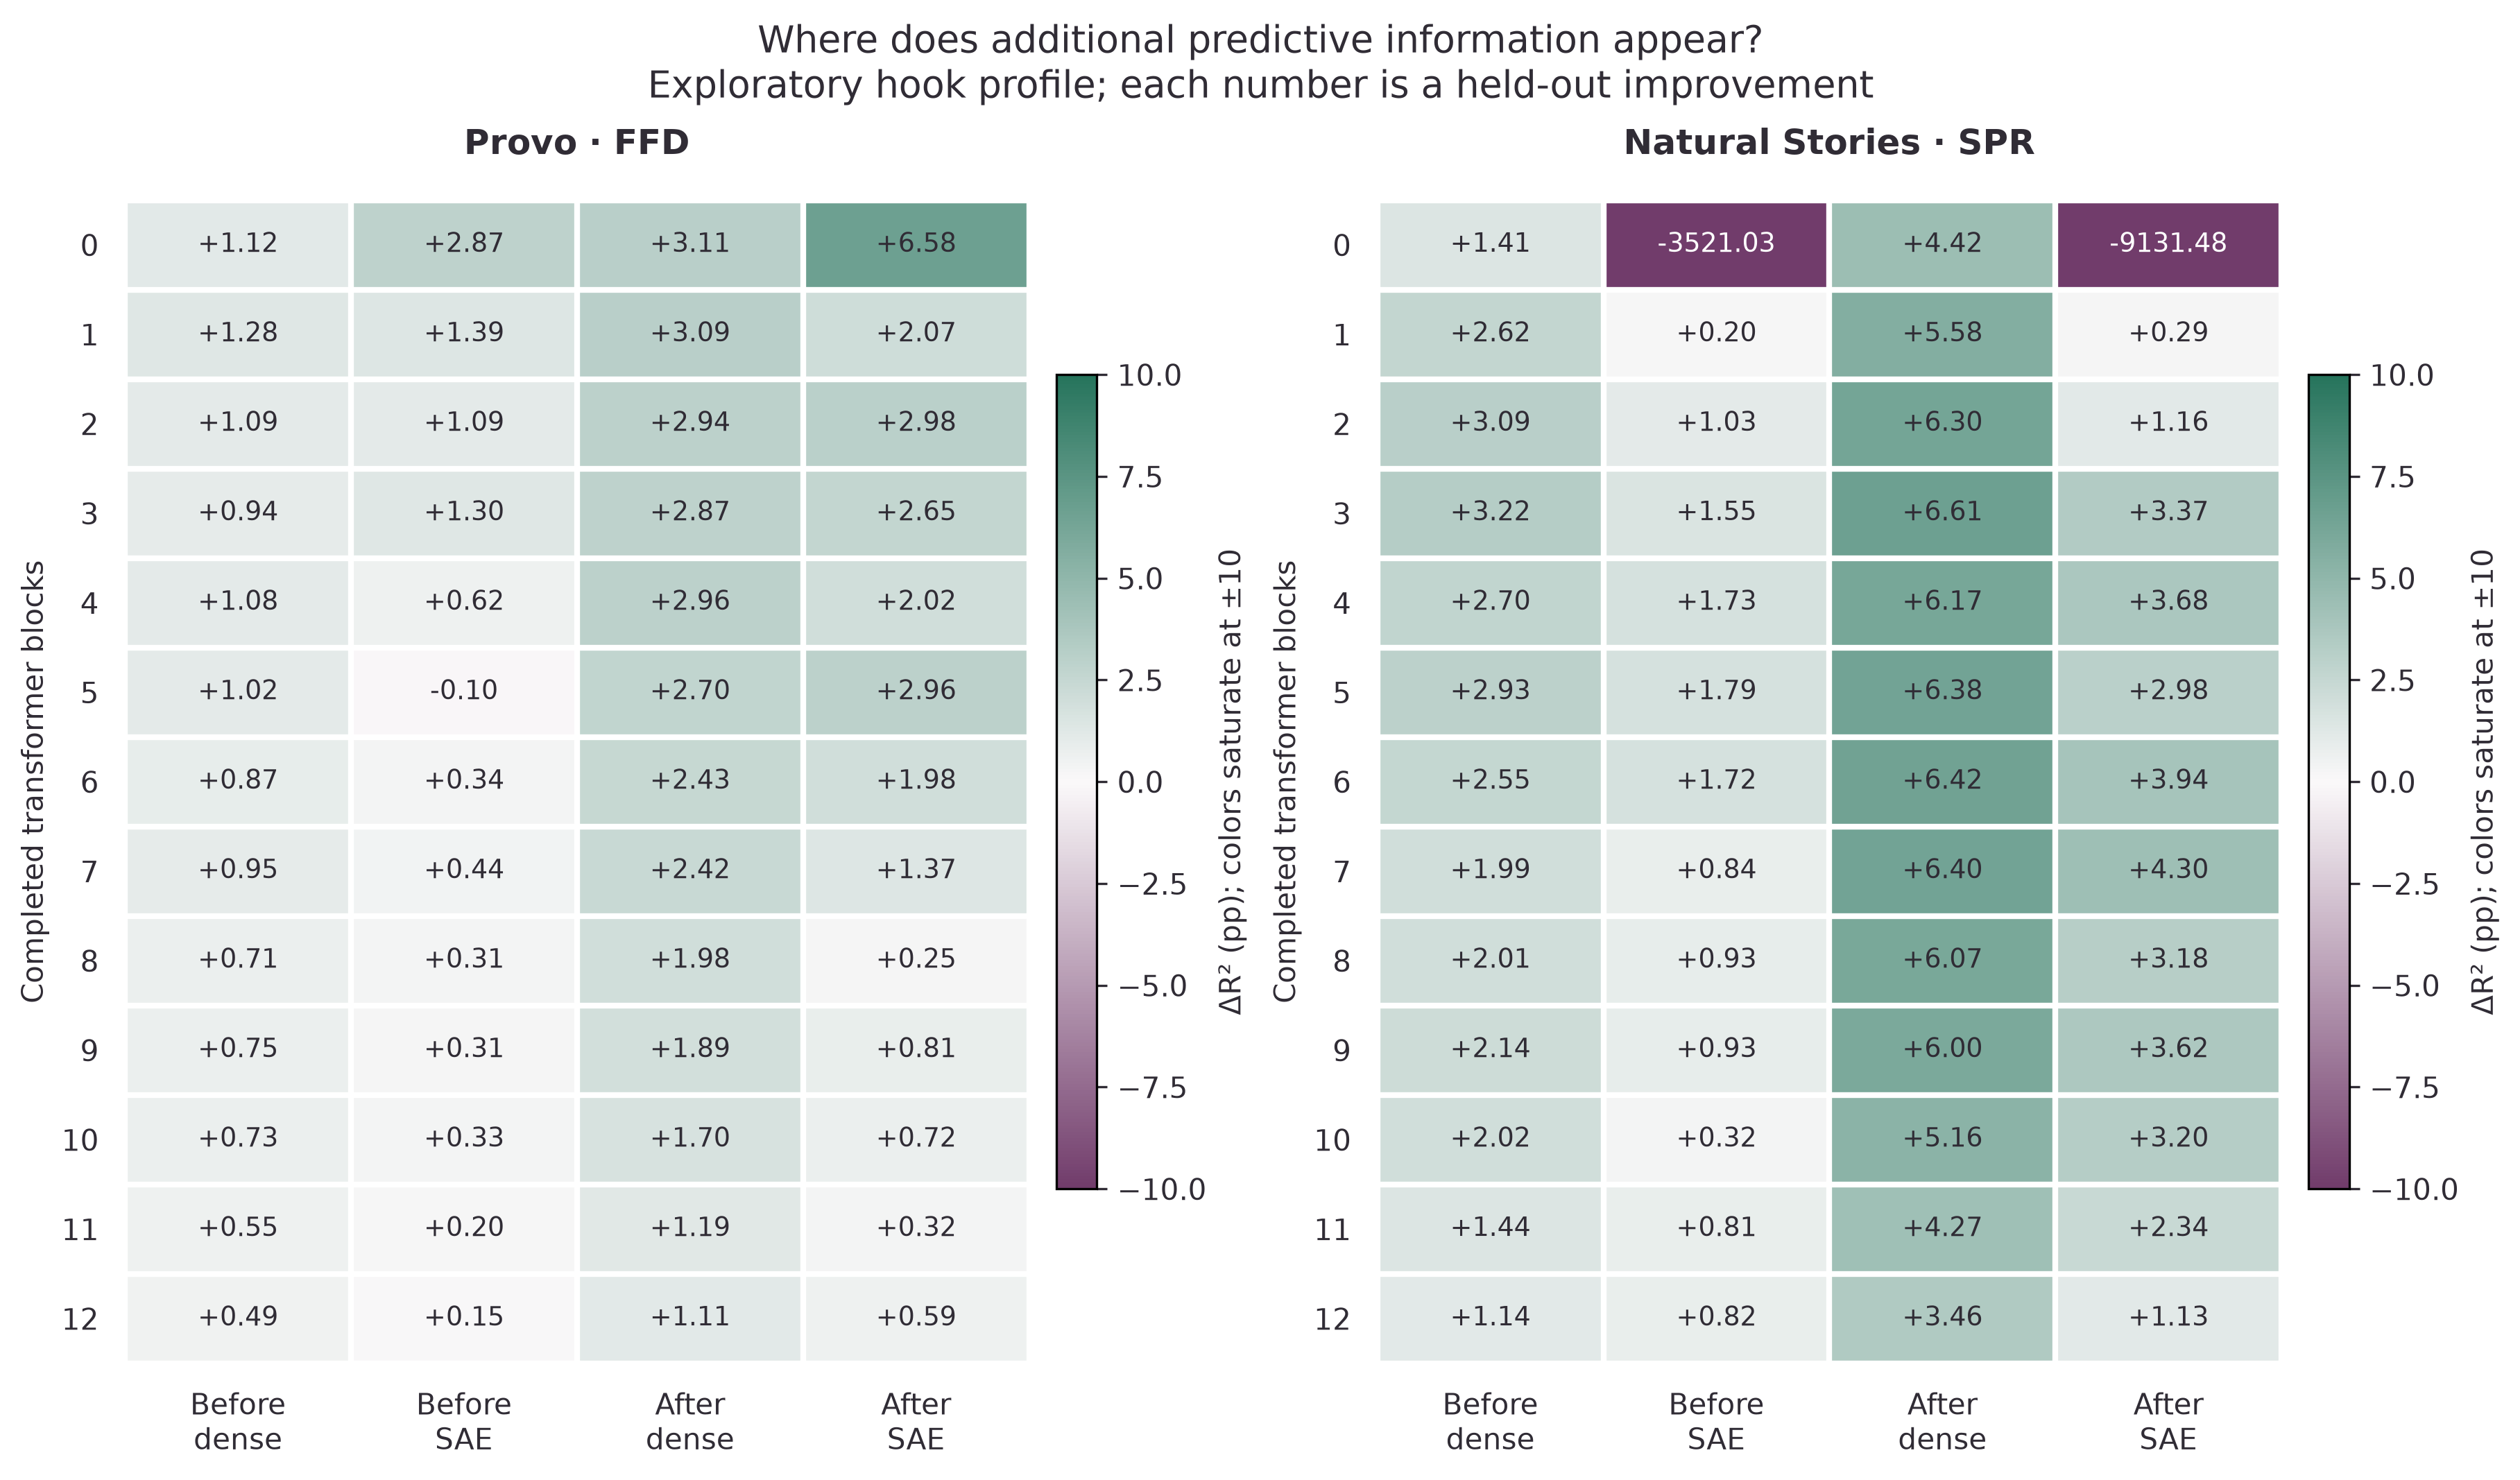

In [4]:
figure("sae_prediction","layer_gain_heatmap")

The hook profile is exploratory. Colors saturate at ±10 pp; printed values retain extreme failures. Natural Stories L01 has an audited feature-scaling failure. Inner validation never selected it for the main Natural Stories comparison. Notebook 04 checks an alternative scaling rule.

In [5]:
display_details("Hook selection counts",load("sae_prediction","hook_selection"))
display_details("Regularization grid boundary counts",load("sae_prediction","regularization_summary"))
display_details("Extreme-error audit",load("sae_prediction","feature_shift_audit"))
display_details("All hook metrics",load("sae_prediction","model_comparison"))

corpus,kind,representation,label,fold_count
natural_stories,post,dense,L03,1
natural_stories,post,dense,L04,2
natural_stories,post,dense,L06,2
natural_stories,post,dense,L07,3
natural_stories,post,dense,L08,2
natural_stories,post,sae,L05,2
natural_stories,post,sae,L07,1
natural_stories,post,sae,L08,5
natural_stories,post,sae,L09,1
natural_stories,post,sae,L10,1


corpus,kind,representation,fits,smallest_alpha_choices,largest_alpha_choices
natural_stories,post,dense,130,0,0
natural_stories,post,sae,130,0,17
natural_stories,prefix,dense,130,0,1
natural_stories,prefix,sae,130,0,53
provo,post,dense,715,0,0
provo,post,sae,715,0,246
provo,prefix,dense,715,0,4
provo,prefix,sae,715,0,419


corpus,kind,label,row_uid,word,prediction,observed_log_rt,feature_id,activation,training_max,training_sd,training_active_rows,feature_contribution,coefficient_reproduction_error
natural_stories,prefix,L01,natural_stories:8:908,or,75.246,5.776,16980,0.777,0.000,0.000,12,69.495,0.000
natural_stories,post,L01,natural_stories:8:907,saucer,117.637,5.759,16980,0.777,0.000,0.000,12,111.836,0.000


corpus,kind,representation,label,r2,delta_r2,ci_low,ci_high,rmse_log_ms,mae_log_ms,texts_improved,n_texts,n_rows,max_abs_error_log_ms,largest_error_share_of_sse
provo,prefix,dense,L01,0.205,0.011,0.006,0.016,0.094,0.072,44,55,2743,0.408,0.007
provo,prefix,dense,L02,0.207,0.013,0.008,0.018,0.094,0.072,42,55,2743,0.403,0.007
provo,prefix,dense,L03,0.205,0.011,0.007,0.015,0.094,0.072,43,55,2743,0.402,0.007
provo,prefix,dense,L04,0.204,0.009,0.006,0.013,0.094,0.072,42,55,2743,0.408,0.007
provo,prefix,dense,L05,0.205,0.011,0.007,0.015,0.094,0.072,40,55,2743,0.407,0.007
provo,prefix,dense,L06,0.204,0.010,0.006,0.014,0.094,0.072,40,55,2743,0.406,0.007
provo,prefix,dense,L07,0.203,0.009,0.005,0.013,0.094,0.072,38,55,2743,0.406,0.007
provo,prefix,dense,L08,0.204,0.009,0.005,0.014,0.094,0.072,40,55,2743,0.404,0.007
provo,prefix,dense,L09,0.201,0.007,0.003,0.012,0.095,0.072,39,55,2743,0.405,0.007
provo,prefix,dense,L10,0.202,0.008,0.003,0.012,0.095,0.072,33,55,2743,0.407,0.007
